In [41]:
import numpy as np
import io
import matplotlib.pyplot as plt

In [42]:
x = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

In [43]:
n_x = 2  
n_y = 1  
n_h = 2   
m = x.shape[0]
lr = 0.1

In [44]:
w1 = np.random.randn(n_x, n_h)
w2 = np.random.randn(n_h, n_y)


In [45]:
losses = []
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [46]:
def forward_prop(w1, w2, x):

    z1 = np.dot(x, w1)
    a1 = sigmoid(z1)

    z2 = np.dot(a1, w2)
    a2 = sigmoid(z2)

    return z1, a1, z2, a2

In [47]:

def back_prop(m, w1, w2, z1, a1, z2, a2, y):

    dz2 = a2 - y
    dw2 = (1/m) * np.dot(a1.T, dz2)

    dz1 = np.dot(dz2, w2.T) * (a1 * (1 - a1))
    dw1 = (1/m) * np.dot(x.T, dz1)

    return dw1, dw2
    

In [48]:
iterations = 10000

for i in range(iterations):

    z1 = np.dot(x, w1)
    a1 = sigmoid(z1)

    z2 = np.dot(a1, w2)
    a2 = sigmoid(z2)

    loss = np.mean((y - a2) ** 2)
    losses.append(loss)

    dw1, dw2 = back_prop(m, w1, w2, z1, a1, z2, a2, y)

    w1 = w1 - lr * dw1
    w2 = w2 - lr * dw2

Text(0, 0.5, 'Loss value')

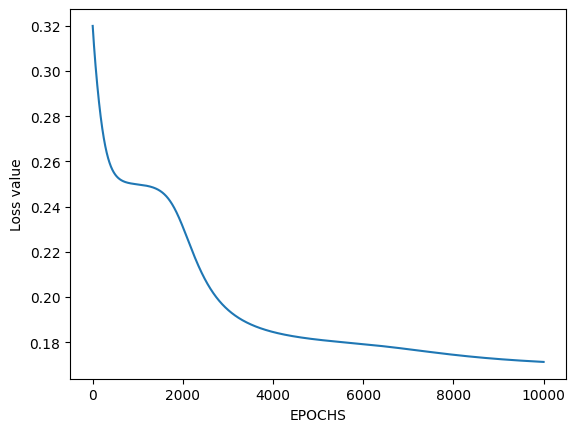

In [52]:

plt.plot(losses)
plt.xlabel("EPOCHS")
plt.ylabel("Loss value")

In [53]:

def predict(w1, w2, input):

    z1 = np.dot(input, w1)
    a1 = sigmoid(z1)

    z2 = np.dot(a1, w2)
    a2 = sigmoid(z2)

    predictions = (a2 > 0.5).astype(int)

    return predictions
    

In [54]:
print(predict(w1, w2, x))

[[0]
 [1]
 [1]
 [1]]
